In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.ndimage import binary_opening, binary_closing

# Sharp

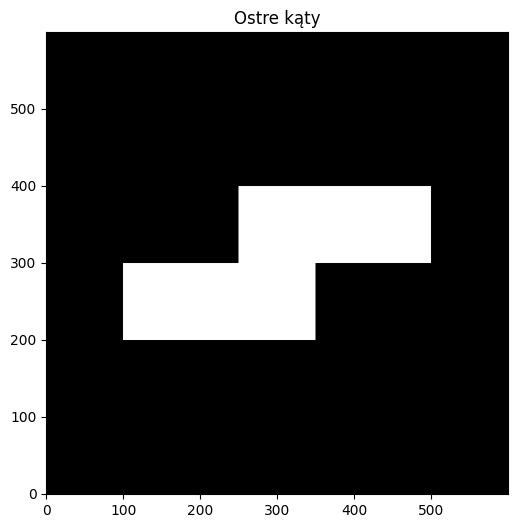

Maksymalne ciśnienie, ostre kąty: 59.43792862652886


In [2]:
nz = 600
nx = 600

ds = 0.02
dt = 0.002
et = 0.5
fpeak = 30.0

v_ground = 1000.0
v_air = 343.0

V = np.full((nz, nx), v_ground)

V[200:300, 100:350] = v_air
V[300:400, 250:350] = v_air
V[300:400, 250:500] = v_air

plt.figure(figsize=(6, 6))
plt.imshow(V, cmap='gray_r', origin='lower')
plt.title("Ostre kąty")
plt.show()

vmax = np.max(V)
dtr = 0.4 * ds / (vmax * np.sqrt(2))

p = np.zeros((nz, nx))
pm = np.zeros((nz, nx))
pp = np.zeros((nz, nx))

src_z = 250
src_x = 140

rec_z = 350
rec_x = 460

nrec = int(et / dt) + 1
trace_sharp = np.zeros(nrec)

frames_sharp = []
times_sharp = []

k = 0
kk = 0
kkk = 0

while True:
    k += 1
    kk += 1
    t = k * dtr

    pp[1:-1, 1:-1] = (
        2.0 * p[1:-1, 1:-1]
        - pm[1:-1, 1:-1]
        + (dtr * dtr / (ds * ds)) * V[1:-1, 1:-1]**2 *
        (
            p[2:, 1:-1] + p[:-2, 1:-1] +
            p[1:-1, 2:] + p[1:-1, :-2] -
            4.0 * p[1:-1, 1:-1]
        )
    )

    a = np.pi * fpeak * (t - 1.0 / fpeak)
    s = np.exp(-(a * a)) * (1.0 - 2.0 * a * a)
    pp[src_z, src_x] += s

    pp[:, 0] = 0.0
    pp[:, -1] = 0.0
    pp[0, :] = 0.0
    pp[-1, :] = 0.0

    pm[:] = p
    p[:] = pp

    if kk * dtr >= dt:
        kk = 0

        if kkk < nrec:
            trace_sharp[kkk] = p[rec_z, rec_x]

            if kkk % 5 == 0:
                frames_sharp.append(p.copy())
                times_sharp.append(kkk * dt)

            kkk += 1

        if kkk >= nrec:
            break

print("Maksymalne ciśnienie, ostre kąty:", np.max(np.abs(trace_sharp)))

In [3]:
all_max = max(np.max(frame) for frame in frames_sharp)
all_min = min(np.min(frame) for frame in frames_sharp)


fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(frames_sharp[0], cmap='YlOrRd', origin='lower', vmin=all_min, vmax=all_max)
txt = ax.text(10, 570, "", color='blue', fontsize=12)

trench = (V == 343.0)
ax.contour(trench, levels=[0.5], colors='black', linewidths=1, linestyles='dashed')

ax.set_title("Propagacja fali - ostre kąty")

def update_sharp(i):
    frame = frames_sharp[i]
    im.set_data(frame)
    txt.set_text(f"t = {times_sharp[i]:.3f} s")
    return [im, txt]

ani_sharp = animation.FuncAnimation(
    fig,
    update_sharp,
    frames=len(frames_sharp),
    interval=300,
    blit=True,
    repeat=False
)

plt.close(fig)
HTML(ani_sharp.to_html5_video())

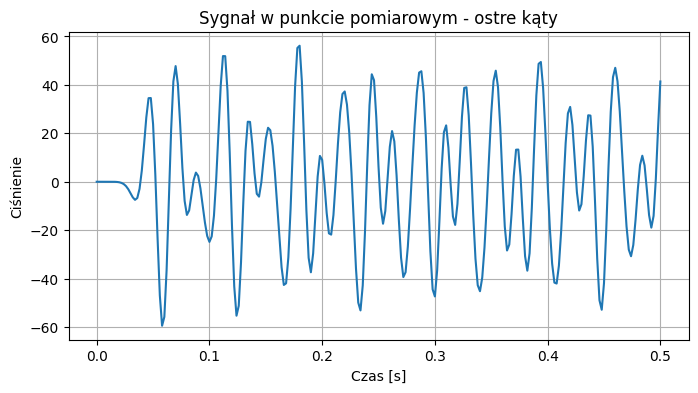

In [4]:
t_axis = np.arange(nrec) * dt

plt.figure(figsize=(8, 4))
plt.plot(t_axis, trace_sharp)
plt.xlabel("Czas [s]")
plt.ylabel("Ciśnienie")
plt.title("Sygnał w punkcie pomiarowym - ostre kąty")
plt.grid()
plt.show()

# Round

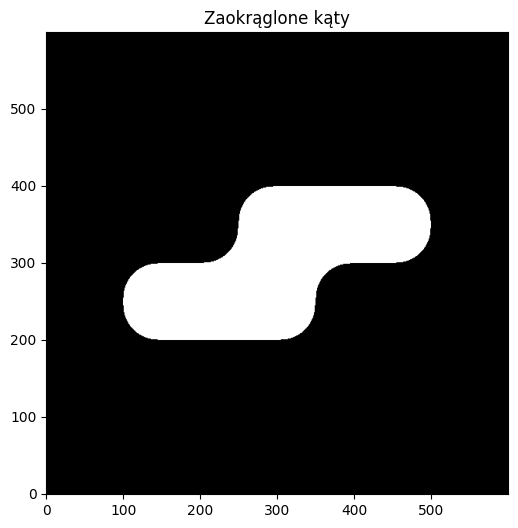

Maksymalne ciśnienie, zaokrąglone kąty: 57.710866357481635


In [12]:
nz = 600
nx = 600

ds = 0.02
dt = 0.002
et = 0.5
fpeak = 30.0

v_ground = 1000.0
v_air = 343.0

V = np.full((nz, nx), v_ground)

mask = np.zeros((nz, nx), dtype=bool)

mask[200:300, 100:350] = True
mask[300:400, 250:350] = True
mask[300:400, 250:500] = True

r = 45
zz, xx = np.ogrid[-r:r+1, -r:r+1]
disk = xx**2 + zz**2 <= r**2

mask_round = binary_opening(mask, structure=disk)
mask_round = binary_closing(mask_round, structure=disk)

V[mask_round] = v_air

plt.figure(figsize=(6, 6))
plt.imshow(V, cmap='gray_r', origin='lower')
plt.title("Zaokrąglone kąty")
plt.show()

vmax = np.max(V)
dtr = 0.4 * ds / (vmax * np.sqrt(2))

p = np.zeros((nz, nx))
pm = np.zeros((nz, nx))
pp = np.zeros((nz, nx))

src_z = 250
src_x = 140

rec_z = 350
rec_x = 460

nrec = int(et / dt) + 1
trace_round = np.zeros(nrec)

frames_round = []
times_round = []

k = 0
kk = 0
kkk = 0

while True:
    k += 1
    kk += 1
    t = k * dtr

    pp[1:-1, 1:-1] = (
        2.0 * p[1:-1, 1:-1]
        - pm[1:-1, 1:-1]
        + (dtr * dtr / (ds * ds)) * V[1:-1, 1:-1]**2 *
        (
            p[2:, 1:-1] + p[:-2, 1:-1] +
            p[1:-1, 2:] + p[1:-1, :-2] -
            4.0 * p[1:-1, 1:-1]
        )
    )

    a = np.pi * fpeak * (t - 1.0 / fpeak)
    s = np.exp(-(a * a)) * (1.0 - 2.0 * a * a)
    pp[src_z, src_x] += s

    pp[:, 0] = 0.0
    pp[:, -1] = 0.0
    pp[0, :] = 0.0
    pp[-1, :] = 0.0

    pm[:] = p
    p[:] = pp

    if kk * dtr >= dt:
        kk = 0

        if kkk < nrec:
            trace_round[kkk] = p[rec_z, rec_x]

            if kkk % 5 == 0:
                frames_round.append(p.copy())
                times_round.append(kkk * dt)

            kkk += 1

        if kkk >= nrec:
            break

print("Maksymalne ciśnienie, zaokrąglone kąty:", np.max(np.abs(trace_round)))

In [13]:
all_max_round = max(np.max(frame) for frame in frames_round)
all_min_round = min(np.min(frame) for frame in frames_round)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    frames_round[0],
    cmap='YlOrRd',
    origin='lower',
    vmin=all_min_round,
    vmax=all_max_round
)
txt = ax.text(10, 570, "", color='blue', fontsize=12)

trench_round = (V == 343.0)
ax.contour(trench_round, levels=[0.5], colors='black', linewidths=1, linestyles='dashed')

ax.set_title("Propagacja fali - zaokrąglone kąty")

def update_round(i):
    frame = frames_round[i]
    im.set_data(frame)
    txt.set_text(f"t = {times_round[i]:.3f} s")
    return [im, txt]

ani_round = animation.FuncAnimation(
    fig,
    update_round,
    frames=len(frames_round),
    interval=300,
    blit=True,
    repeat=False
)

plt.close(fig)
HTML(ani_round.to_html5_video())

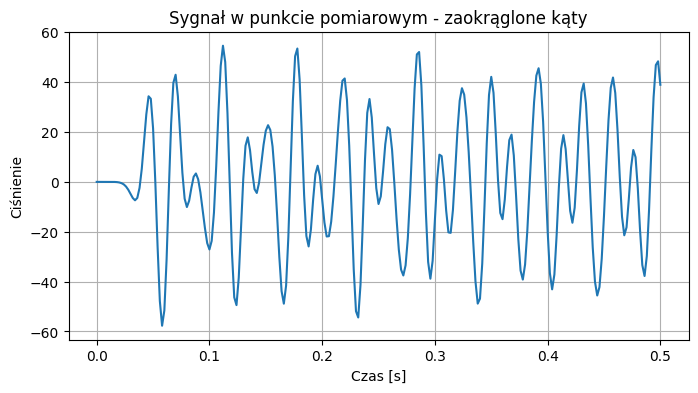

In [14]:
t_axis = np.arange(nrec) * dt

plt.figure(figsize=(8, 4))
plt.plot(t_axis, trace_round)
plt.xlabel("Czas [s]")
plt.ylabel("Ciśnienie")
plt.title("Sygnał w punkcie pomiarowym - zaokrąglone kąty")
plt.grid()
plt.show()

# Comparison

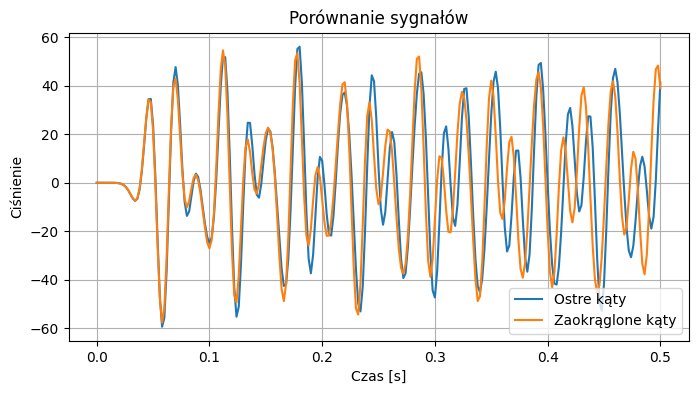

Max ostre: 59.43792862652886
Max zaokrąglone: 57.710866357481635


In [17]:
t_axis = np.arange(nrec) * dt

plt.figure(figsize=(8, 4))
plt.plot(t_axis, trace_sharp, label="Ostre kąty")
plt.plot(t_axis, trace_round, label="Zaokrąglone kąty")
plt.xlabel("Czas [s]")
plt.ylabel("Ciśnienie")
plt.title("Porównanie sygnałów")
plt.legend()
plt.grid()
plt.show()

print("Max ostre:", np.max(np.abs(trace_sharp)))
print("Max zaokrąglone:", np.max(np.abs(trace_round)))

W wariancie z ostrymi kątami zaobserwowano nieco wyższe maksymalne ciśnienie niż w przypadku zaokrąglonych zakrętów. Może to wynikać z silniejszych odbić i lokalnej koncentracji energii fali na ostrych krawędziach. W przypadku zaokrągleń fala propaguje się bardziej płynnie, co prowadzi do większego rozproszenia energii i nieco niższych amplitud.